## Evaluation Metrics Playbook

### Objective

The goal of this notebook is to understand how classification models should be evaluated in practical machine learning systems.

Rather than focusing on mathematical derivations, this notebook emphasizes:

- practical evaluation behavior
- business-oriented metric interpretation
- imbalanced classification challenges
- threshold-driven decision making
- probability reliability
- model failure analysis

The focus of this notebook is understanding practical evaluation behavior in real ML systems rather than mathematical derivations of metrics.

---

### Business Framing

We frame this problem as:

> Predicting whether a customer is likely to respond positively to a marketing campaign.

In this setting:

- False Positives may target uninterested customers, increasing marketing cost
- False Negatives may miss potential buyers and reduce conversions

This makes evaluation metrics important for business decision-making and campaign optimization

## Import Libraries

In [1]:
# Standard library
import random

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local modules
from ml_playbook.config import DATA_DIR

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score, precision_score,\
recall_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve

## Config

In [2]:
# Constants
RANDOM_STATE = 42
TARGET_COL = "Purchased"
TEST_SIZE = 0.25

# Paths
DATA_PATH = DATA_DIR / "Social_Network_Ads.csv"

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Load Dataset

In [3]:
df = pd.read_csv(DATA_PATH, header=0)
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (400, 3)

Data Types:
 Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


**Dataset Overview**

We use the `Social_Network_Ads.csv` dataset containing:
- `Age` -> Customer age
- `EstimatedSalary` -> Estimated annual salary
- `Purchased` -> Whether the customer responded positively to the marketing campaign

This is a binary classification problem where the goal is to predict customer purchase behavior based on demographic information

In [4]:
# Preview
df.head(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [6]:
print(y.value_counts(normalize=True))

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64


**Observation**
- The dataset shows moderate class imbalance
- The positive class (`Purchased = 1`) represents the minority class
- In imbalanced settings, accuracy alone may not reflect true model performance
- Metrics like Precision, Recall, F1-score, and ROC-AUC become more informative

## Train/Test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

**Notes**
- Stratified splitting preserves the original class distribution across training and test datasets
- This is important in imbalanced classification problems because random splitting can accidentally distort minority-class representation

## Column typing

In [8]:
# All columns are numeric
numeric_features = X_train.columns.tolist()

## Preprocessing skeleton

In [9]:
# feature-scaling preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

## Train Logistic Regression Baseline Model

In [10]:
# pipeline with feature scaling
lr_baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
lr_baseline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate Predictions and Probabilities

In [11]:
y_pred = lr_baseline.predict(X_test)
y_prob = lr_baseline.predict_proba(X_test)[:, 1]

In [12]:
# Metrics
lr_baseline_roc_auc = roc_auc_score(y_test, y_prob)
lr_baseline_accuracy = accuracy_score(y_test, y_pred)
lr_baseline_precision = precision_score(y_test, y_pred)
lr_baseline_recall = recall_score(y_test, y_pred)
lr_baseline_f1 = f1_score(y_test, y_pred)

# Confusion matrix
lr_baseline_cm = confusion_matrix(y_test, y_pred)

In [13]:
# Print metrics
print("=== Logistic Regression Baseline Metrics ===\n")

print(f"ROC-AUC  : {lr_baseline_roc_auc:.4f}")
print(f"Accuracy : {lr_baseline_accuracy:.4f}")
print(f"Precision: {lr_baseline_precision:.4f}")
print(f"Recall   : {lr_baseline_recall:.4f}")
print(f"F1-Score : {lr_baseline_f1:.4f}")

=== Logistic Regression Baseline Metrics ===

ROC-AUC  : 0.9102
Accuracy : 0.8400
Precision: 0.8571
Recall   : 0.6667
F1-Score : 0.7500


**Initial Evaluation Observations**
- The model achieves strong ROC-AUC performance, indicating good ranking capability between classes
- Precision is relatively high, meaning most customers predicted as likely buyers actually belong to the positive class
- Recall is lower than Precision, indicating the model still misses some potential buyers
- This creates an important business tradeoff:
    - improving Recall may identify more potential buyers
    - but may also increase marketing spend on uninterested customers
- Accuracy alone does not fully capture these tradeoffs

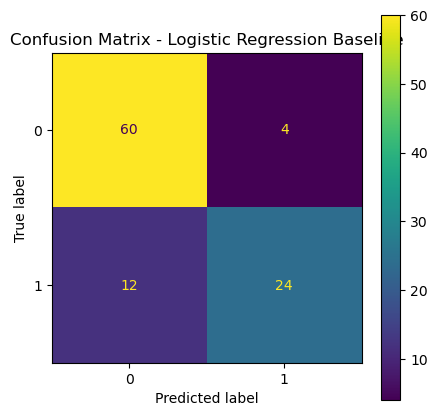

In [14]:
# Display confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay(
    confusion_matrix=lr_baseline_cm,
    display_labels=["0", "1"]
).plot(ax=ax)
ax.set_title("Confusion Matrix - Logistic Regression Baseline")

plt.show()

**Confusion Matrix Interpretation**
- True Negatives: Customers correctly identified as unlikely to purchase
- True Positives: Customers correctly identified as likely to purchase
- False Positives: Customers incorrectly targeted despite low purchase likelihood
- False Negatives: Potential buyers missed by the marketing campaign

In marketing systems, the acceptable balance between False Positives and False Negatives depends on campaign cost, customer reach, and conversion goals

**Confusion Matrix Insights**
- The model correctly identifies most non-buyers (`60` True Negatives)
- The model successfully identifies `24` potential buyers
- Only `4` uninterested customers are incorrectly targeted
- However, `12` potential buyers are still missed

This suggests the current model is relatively conservative in predicting positive outcomes:
- Precision remains high
- But some potential conversions are lost due to lower Recall

# ROC and Precision-Recall Curve Analysis

In the previous section, we evaluated the model using metrics computed at a single classification threshold. However, classification models produce probability scores, and model behavior can change significantly depending on the chosen threshold.

To better understand model performance across all possible thresholds, we use:

- ROC Curves
- Precision-Recall Curves

These curves help evaluate:

- ranking quality
- threshold behavior
- class separation capability
- positive prediction reliability

They are especially useful in imbalanced classification problems where Accuracy alone can become misleading.

## Why Threshold-Independent Evaluation Matters

Metrics like Precision, Recall, and F1-score depend on a specific classification threshold.

Changing the threshold changes:
- predicted labels
- confusion matrix values
- Precision
- Recall
- F1-score

ROC and Precision-Recall curves help evaluate model behavior across all possible thresholds rather than at only one operating point.

## ROC Curve Analysis

- ROC stands for Receiver Operating Characteristic
- ROC Curve plots:
    - True Positive Rate (Recall)
    - vs False Positive Rate
- Each point on the ROC curve represents a different classification threshold
- ROC-AUC measures how well the model ranks positive samples above negative samples across all classification thresholds

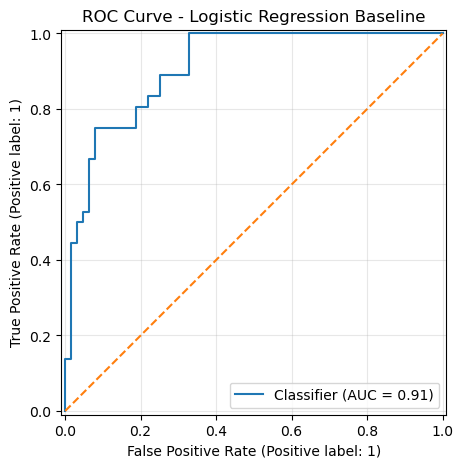

In [15]:
# Plot ROC Curve
fig, ax = plt.subplots(figsize=(5, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax
)
ax.set_title("ROC Curve - Logistic Regression Baseline")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.grid(alpha=0.3)

plt.show()

**ROC Curve Observations**
- The ROC curve stays significantly above the random baseline, indicating strong class separation capability
- The model achieves a ROC-AUC score of approximately `0.91`, suggesting strong ranking performance
- This means the model is generally effective at assigning higher probabilities to likely buyers than non-buyers
- ROC-AUC evaluates ranking quality across all possible classification thresholds rather than performance at a single operating threshold

## Precision-Recall Curve Analysis

- Precision-Recall curves evaluate model performance across different classification thresholds
- Precision measures how many predicted positives are actually positive
- Recall measures how many actual positives are correctly identified
- Each point on the curve represents a different classification threshold

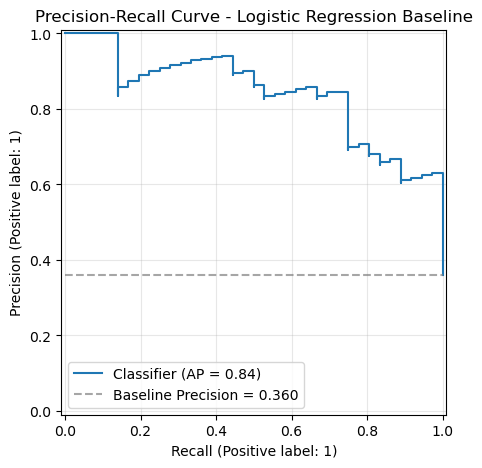

In [16]:
# Plot Precision-Recall Curve
fig, ax = plt.subplots(figsize=(5, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax
)

# Baseline precision
baseline_precision = y_test.mean()

ax.hlines(
    y=baseline_precision,
    xmin=0,
    xmax=1,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label=f"Baseline Precision = {baseline_precision:.3f}"
)

ax.set_title("Precision-Recall Curve - Logistic Regression Baseline")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

**Precision-Recall Curve Observations**
- The model maintains relatively high Precision across a wide range of Recall values
- As Recall increases, Precision gradually decreases, reflecting the tradeoff between identifying more buyers and increasing false positives
- The Average Precision (AP) score of approximately `0.84` indicates strong positive-class prediction performance
- Precision-Recall curves are especially informative for imbalanced classification problems because they focus directly on positive prediction quality

**Baseline Precision Insight**
- The horizontal dashed line represents baseline Precision, which equals the positive-class prevalence in the dataset
- A strong PR curve should stay meaningfully above this baseline across Recall values

**Important Insight**
- Precision-Recall curves focus more directly on the quality and usefulness of positive predictions
- In imbalanced datasets, PR curves often provide more practical insight into model behavior than ROC curves

## ROC-AUC vs PR-AUC

- ROC-AUC evaluates overall ranking quality between classes
- PR-AUC evaluates the quality and reliability of positive predictions
- ROC-AUC is threshold-independent and evaluates ranking behavior across all thresholds
- PR-AUC is more sensitive to False Positives and class imbalance

    | Metric Perspective | Focus |
    |---|---|
    | ROC-AUC | Overall ranking quality |
    | PR-AUC | Positive prediction usefulness |
    | Precision | Correctness of positive predictions |
    | Recall | Ability to capture actual positives |

**Business Interpretation**
- A model with strong ROC-AUC can separate buyers from non-buyers effectively overall
- However, if Precision is low, marketing campaigns may still waste resources targeting many uninterested customers
- PR-AUC helps evaluate whether positive predictions remain reliable as Recall increases
- This becomes especially important when the positive class is relatively rare

**Important Insight**
- A model can achieve strong ROC-AUC performance while still producing poor Precision or Recall at a specific threshold
- Final business performance depends not only on ranking quality, but also on threshold selection and acceptable error tradeoffs

## Key Takeaways

- ROC-AUC evaluates how well the model ranks positive samples above negative samples
- Precision-Recall curves focus more directly on the quality of positive predictions
- ROC-AUC is less sensitive to class imbalance because False Positive Rate is normalized by the large number of negative samples
- PR curves become more informative when the positive class is relatively rare because they focus directly on positive prediction quality
- Precision and Recall depend on the chosen operating threshold
- Strong ranking quality does not always guarantee strong classification performance at a fixed threshold
- Model evaluation should align with business objectives and acceptable error tradeoffs

# Threshold Tuning and Operating Point Analysis

## Why Threshold Selection Matters

Classification models produce probability scores, but final business decisions require converting those probabilities into class predictions.

By default, many classification models use:

- probability >= 0.5 → Positive class
- probability < 0.5 → Negative class

However, the choice of threshold significantly affects model behavior.

Changing the threshold changes:

- Precision
- Recall
- False Positives
- False Negatives
- overall business behavior

As the threshold changes, the same model can become:

- more conservative
- more aggressive
- more precision-oriented
- more recall-oriented

In practical ML systems, threshold selection is often guided by business objectives and acceptable error tradeoffs rather than by a fixed default value.

## Baseline Threshold Evaluation (Threshold = 0.5)

We begin by evaluating the model at the default operating threshold of `0.5`.

This serves as the baseline reference point before analyzing how model behavior changes across different thresholds.

In [17]:
# Print metrics
print("=== Baseline Threshold Evaluation (Threshold = 0.5) ===\n")

print(f"Precision: {lr_baseline_precision:.4f}")
print(f"Recall   : {lr_baseline_recall:.4f}")
print(f"F1-Score : {lr_baseline_f1:.4f}")

# Display confusion matrix
cm_df = pd.DataFrame(
    lr_baseline_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("\nConfusion Matrix:")
display(cm_df)

=== Baseline Threshold Evaluation (Threshold = 0.5) ===

Precision: 0.8571
Recall   : 0.6667
F1-Score : 0.7500

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,60,4
Actual 1,12,24


**Baseline Threshold Observations**
- The default threshold produces relatively high Precision, meaning most targeted customers are genuinely likely buyers
- Recall is comparatively lower, indicating that some potential buyers are still being missed
- The model currently behaves somewhat conservatively, prioritizing prediction correctness over capturing all possible buyers
- Lowering the threshold may improve Recall but could also increase False Positives and marketing cost

## Precision-Recall Tradeoff Across Thresholds

- Precision and Recall change continuously as the classification threshold changes
- Lower thresholds generally increase Recall but may reduce Precision
- Higher thresholds generally increase Precision but may reduce Recall
- Threshold selection controls how aggressively or conservatively the model predicts the positive class

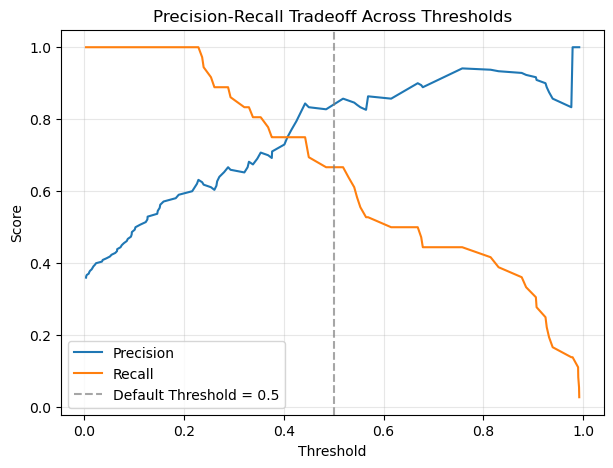

In [18]:
# Compute precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot Precision and Recall vs Threshold
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

ax.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

# Default threshold reference
ax.axvline(
    x=0.5,
    linestyle="--",
    color="gray",
    alpha=0.7,
    label="Default Threshold = 0.5"
)

ax.set_title("Precision-Recall Tradeoff Across Thresholds")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

**Threshold Tradeoff Observations**
- At lower thresholds, the model predicts the positive class more aggressively, resulting in higher Recall
- However, lower thresholds also increase False Positives, reducing Precision
- As the threshold increases, the model becomes more conservative, improving Precision while reducing Recall
- Around the middle threshold range, Precision and Recall achieve a more balanced tradeoff
- The choice of threshold should depend on business priorities rather than a fixed default value

**Important Insight**
- The model itself does not change across thresholds
- Only the decision boundary changes
- Threshold tuning allows the same model to operate differently under different business requirements

## Threshold-wise Confusion Matrix Analysis

In [19]:
thresholds_to_evaluate = [0.3, 0.5, 0.7]

results = []

for threshold in thresholds_to_evaluate:

    # Generate predictions
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    # Metrics
    threshold_precision = precision_score(
        y_test,
        y_pred_threshold
    )

    threshold_recall = recall_score(
        y_test,
        y_pred_threshold
    )

    threshold_f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    # Store results
    results.append({
        "Threshold": threshold,
        "Precision": round(threshold_precision, 4),
        "Recall": round(threshold_recall, 4),
        "F1-Score": round(threshold_f1, 4),
        "Predicted Positives": tp + fp,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn     
    })

# Create dataframe
threshold_analysis_df = pd.DataFrame(results)

display(threshold_analysis_df)

,Threshold,Precision,Recall,F1-Score,Predicted Positives,TP,FP,TN,FN
0,0.3,0.6522,0.8333,0.7317,46,30,16,48,6
1,0.5,0.8571,0.6667,0.7500,28,24,4,60,12
2,0.7,0.9412,0.4444,0.6038,17,16,1,63,20


**Threshold-wise Confusion Matrix Observations**
- Lower thresholds increase positive predictions, improving Recall but also increasing False Positives
- Higher thresholds make the model more conservative, improving Precision while increasing False Negatives
- At threshold `0.3`, the model captures more potential buyers but significantly increases campaign targeting volume
- At threshold `0.7`, the model becomes highly selective, reducing unnecessary targeting but missing many potential buyers
- Threshold `0.5` achieves the highest F1-score among the evaluated thresholds, indicating a stronger overall balance between Precision and Recall

## Business Tradeoff Interpretation

Threshold selection directly affects how aggressively the business targets potential customers.

Lower thresholds:
- increase customer coverage
- improve Recall
- reduce missed opportunities
- but may increase unnecessary marketing spend due to more False Positives

Higher thresholds:
- improve Precision
- reduce unnecessary targeting
- lower campaign costs
- but may miss genuine potential buyers

This demonstrates that evaluation metrics are closely tied to operational and business decisions rather than being purely statistical measures.

## Choosing Thresholds Based on Business Objectives

There is no universally optimal classification threshold.

The best threshold depends on:
- business priorities
- acceptable error tradeoffs
- operational constraints
- campaign budget
- risk tolerance

Examples:

- If maximizing customer reach is important, a lower threshold may be preferred to improve Recall
- If reducing unnecessary marketing spend is more important, a higher threshold may be preferred to improve Precision

Threshold tuning allows the same model to operate differently under different business requirements without retraining the model itself.

## Key Takeaways

- Classification thresholds directly influence model behavior and business outcomes
- Threshold tuning controls how aggressively or conservatively a model predicts the positive class
- The same underlying model can produce very different operational and business outcomes depending on the selected classification threshold
- Threshold tuning helps align model behavior with business objectives and operational constraints
- Strong model performance depends not only on ranking quality, but also on selecting an appropriate operating threshold
- In real-world ML systems, threshold tuning is often revisited continuously as business objectives and operating conditions evolve